First 5 Rows of Dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Shape:
(1338, 7)

Dataset Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-nu

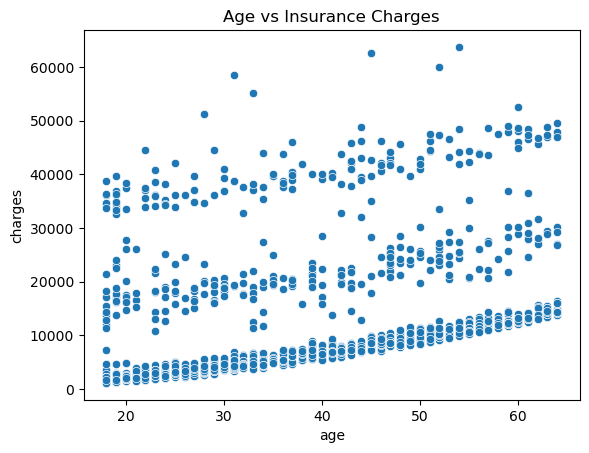

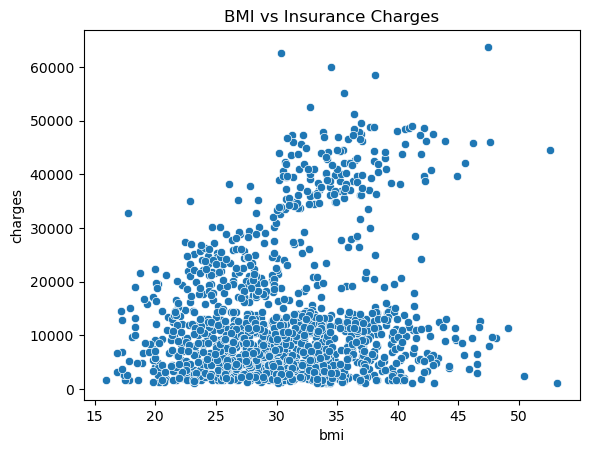

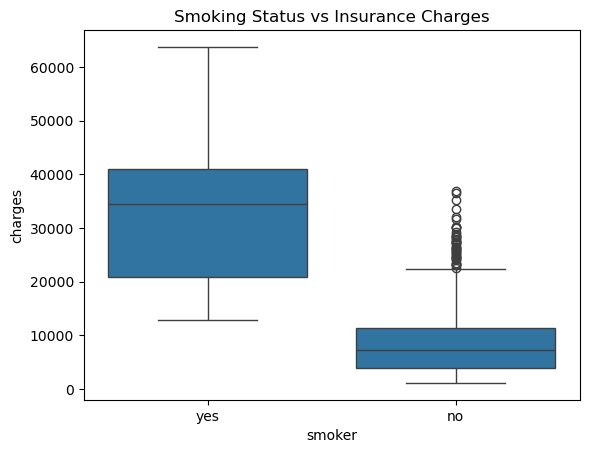


Dataset after Encoding:
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  

Model Evaluation:
MAE: 4181.194473753654
RMSE: 5796.284659276274


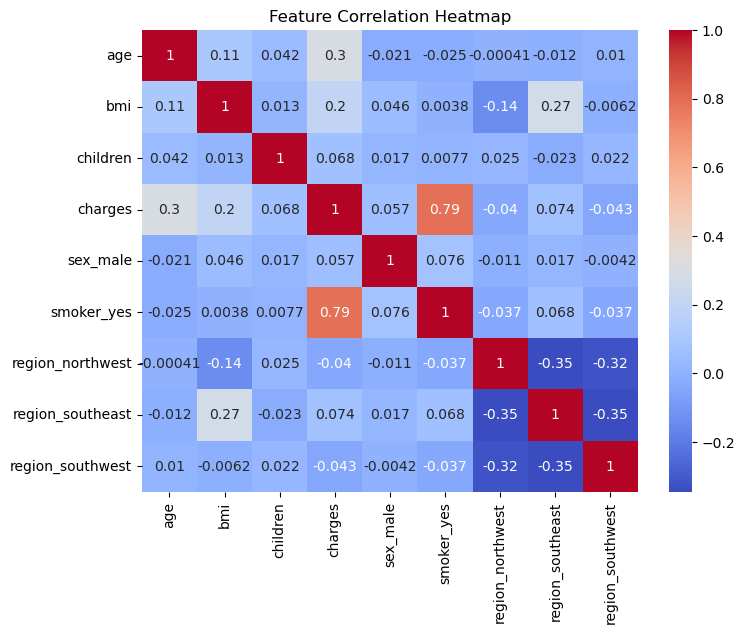

In [2]:
# Task 4: Predicting Insurance Claim Amount
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load Dataset
data = pd.read_csv("insurance.csv")

# Display first 5 rows
print("First 5 Rows of Dataset:")
print(data.head())

# Explore Dataset
print("\nDataset Shape:")
print(data.shape)

print("\nDataset Columns:")
print(data.columns)

print("\nDataset Info:")
print(data.info())

print("\nStatistical Summary:")
print(data.describe())

# Check Missing Values
print("\nMissing Values:")
print(data.isnull().sum())

# Data Visualization
# Age vs Insurance Charges
plt.figure()
sns.scatterplot(x="age", y="charges", data=data)
plt.title("Age vs Insurance Charges")
plt.show()

# BMI vs Insurance Charges
plt.figure()
sns.scatterplot(x="bmi", y="charges", data=data)
plt.title("BMI vs Insurance Charges")
plt.show()

# Smoking Status vs Charges
plt.figure()
sns.boxplot(x="smoker", y="charges", data=data)
plt.title("Smoking Status vs Insurance Charges")
plt.show()

# Encode Categorical Variables
# Convert categorical columns to numeric using one-hot encoding
data = pd.get_dummies(data, drop_first=True)

print("\nDataset after Encoding:")
print(data.head())

# Feature Selection
# Independent variables
X = data.drop("charges", axis=1)

# Target variable
y = data["charges"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression Model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

#  Model Evaluation
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Evaluation:")
print("MAE:", mae)
print("RMSE:", rmse)

# Feature Correlation
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()